#EE470 Fall 2025 Course Project Plant Anomaly Classification Challenge
**Group 3**
* **Mustafa Gökhan Oyanık**
* **Yusuf Erim Bulca**

# Cell 1: Imports and Setup

In [ ]:
!pip install tensorflow

In [ ]:
! gdown  --id 1JnCafgKC88tlvUxBrWFCzVuJM2TDeaLu

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1JnCafgKC88tlvUxBrWFCzVuJM2TDeaLu
From (redirected): https://drive.google.com/uc?id=1JnCafgKC88tlvUxBrWFCzVuJM2TDeaLu&confirm=t&uuid=193b5d27-b3c9-4857-80af-93207d287ccc
To: /content/EEtrain.zip
100% 289M/289M [00:05<00:00, 52.9MB/s]


In [ ]:
import zipfile
import os

# Define the path to the zip file and the extraction directory
zip_file_path = '/content/EEtrain.zip'
extract_dir = '/content/train_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}' successfully.")

# Verify contents
print("Contents of the extracted directory:")
print(os.listdir(extract_dir))


'/content/EEtrain.zip' unzipped to '/content/train_data' successfully.
Contents of the extracted directory:
['__MACOSX', 'train']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

# Check for GPU availability
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow Version: 2.19.0
GPU Available: True


# Cell 2: Configuration

In [ ]:
# CONFIGURATION

DATA_DIR = '/content/train_data/train'
BATCH_SIZE = 32
IMG_SIZE = (224, 224) #for ResNet
SEED = 123

print(f"Data directory set to: {DATA_DIR}")

Data directory set to: /content/train_data/train


# Cell 3: Load Data and Split
*   Loads images
*   Splits them 80% for training and 20% for validation


In [ ]:
# Load Data

# 1. Load Training Data
print("Loading Training Set...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 2. Load Validation Data
print("\nLoading Validation Set...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 3. Get Class Names
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nFound {num_classes} classes: {class_names}")

# NO OPTIMIZATIONS (removed cache/shuffle/prefetch to save RAM)
print("Data loaded in Safe Mode.")

Loading Training Set...
Found 31327 files belonging to 16 classes.
Using 25062 files for training.

Loading Validation Set...
Found 31327 files belonging to 16 classes.
Using 6265 files for validation.

Found 16 classes: ['Spodoptera_frugiperda_p', 'alternaria_d', 'alternaria_mite_d', 'bacterial_floundering_d', 'blossom_end_rot_d', 'caterpillars_p', 'fusarium_d', 'healthy_fruit', 'healthy_leaf', 'helicoverpa_armigera_p', 'mite_d', 'nitrogen_exces_d', 'sunburn_d', 'tomato_late_blight', 'tuta_absoluta_p', 'virosis_d']
Data loaded in Safe Mode.


# Cell 4: Visualize Data


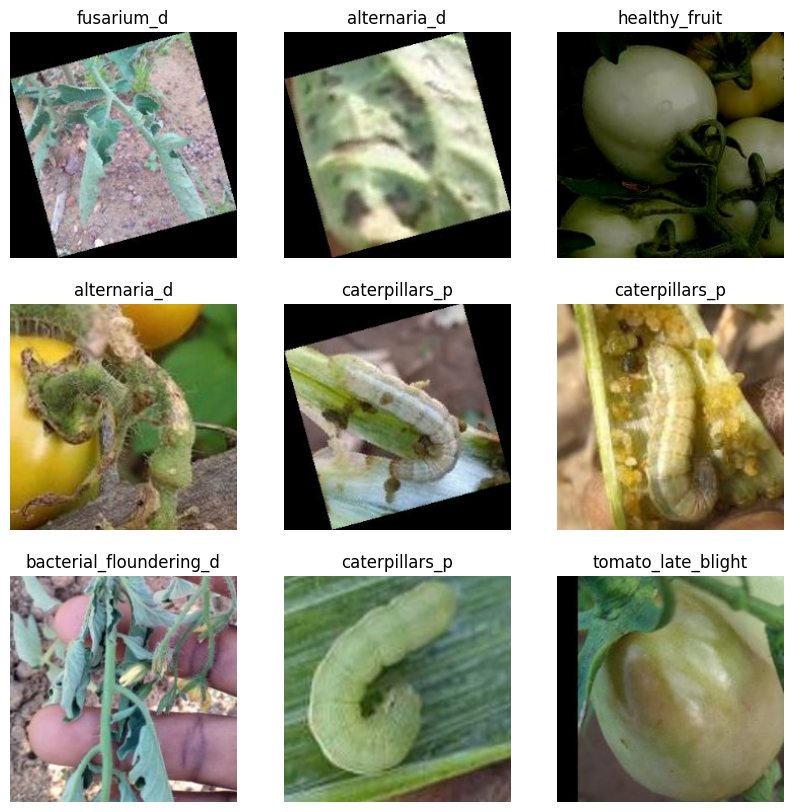

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

# Cell 5: Building the Model (ResNet50)
We used Transfer Learning with ResNet50

In [ ]:

#Building Model with Augmentation


#1.Define Data Augmentation

data_augmentation = tf.keras.Sequential([
  # Geometric Augmentations
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2), # Rotates image by up to 20% (approx 72 degrees)
  layers.RandomZoom(height_factor=0.2, width_factor=0.2), # Random scale/crop effect

  # Color Augmentations (The "Color Jitter")
  # Helps model handle shadows and different lighting conditions
  layers.RandomBrightness(0.2), # Randomly darkens/brightens by 20%
  layers.RandomContrast(0.2),   # Randomly adjusts contrast by 20%
])

print("Augmentation pipeline created.")

# 2.Load the Pre-trained Model (ResNet50)
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3), #Expected image size (width, height, channels).
    include_top=False, #We will add our custom classification head later
    weights='imagenet' #Model is initialized with weights from ImageNet
)
base_model.trainable = False

#3. Create the Classification Head
inputs = tf.keras.Input(shape=(224, 224, 3))

# APPLY AUGMENTATION
x = data_augmentation(inputs)

# ResNet Preprocessing
x = tf.keras.applications.resnet50.preprocess_input(x)

# Pass through base model
x = base_model(x, training=False) #extract features
x = layers.GlobalAveragePooling2D()(x) #creates single feature vector
x = layers.Dropout(0.2)(x) #dropout layer to prevent overfitting

outputs = layers.Dense(num_classes,
                       activation='softmax')(x) #final classification layer
                       #softmax activation
model = models.Model(inputs, outputs)

# 4. Compile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', #loss function for multi-classed problems
              metrics=['accuracy']) #Use Adam Optimizer

model.summary()

Augmentation pipeline created.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     32,784 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,620,496 (90.11 MB)

 Trainable params: 32,784 (128.06 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Cell 6: Train the Model


In [ ]:
# Define the Checkpoint
# saves a file 'best_model.keras' every time accuracy hits a new high score
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# Early Stopping
# stops training if accuracy stops improving for 5 epochs (saves time)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

print("training...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint, early_stopping] # callbacks here
)

training...
Epoch 1/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7053 - loss: 0.9419
Epoch 1: val_accuracy improved from -inf to 0.91764, saving model to best_model.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 143s 167ms/step - accuracy: 0.7054 - loss: 0.9414 - val_accuracy: 0.9176 - val_loss: 0.2587
Epoch 2/30
783/784 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8907 - loss: 0.3402
Epoch 2: val_accuracy improved from 0.91764 to 0.93855, saving model to best_model.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 134s 170ms/step - accuracy: 0.8907 - loss: 0.3401 - val_accuracy: 0.9385 - val_loss: 0.1983
Epoch 3/30
783/784 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9113 - loss: 0.2723
Epoch 3: val_accuracy improved from 0.93855 to 0.94126, saving model to best_model.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 135s 172ms/step - accuracy: 0.9113 - loss: 0.2722 - val_accuracy: 0.9413 - val_loss: 0.1701
Epoch 4/30
783/784 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9150 - loss: 0.2462
Epoch 4: 

# Cell 7: Plot Results

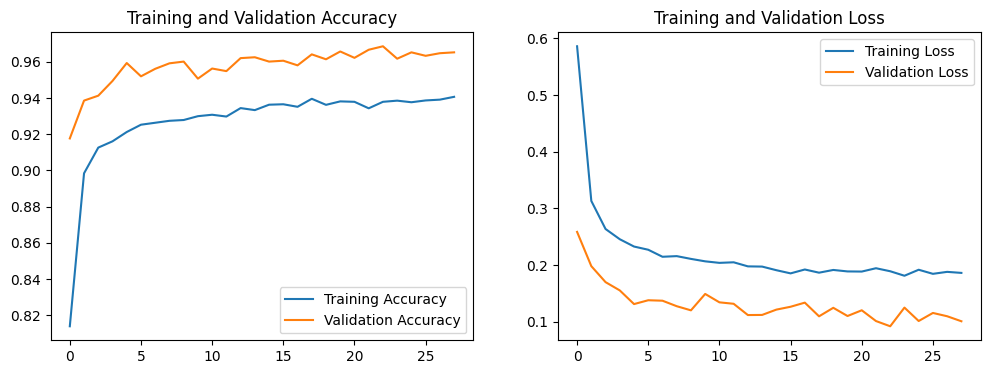

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()